In [12]:
from pathlib import Path
import sys

import torch
import numpy as np
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import TUDataset

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import pytorch_to_networkx, networkx_to_igraph, DatasetPT
from src.graph_analysis import analyze_single_graph, calculate_annd_error
from src.generate_datasets import generate_graph
from notebooks.visualization_utils import plot_graph, plot_annd

In [13]:
DATASET = "BZR"
METHOD = "anndg"  # Options: "padma", "anndg", etc.
IDX = 330

try:
    dataset = DatasetPT(PROJECT_ROOT / "data" / DATASET / f"{DATASET}_original.pt")
except:
    dataset = TUDataset(PROJECT_ROOT / "data", name=DATASET)

GRAPH_NX = pytorch_to_networkx(dataset[IDX])
GRAPH_IG = networkx_to_igraph(GRAPH_NX)

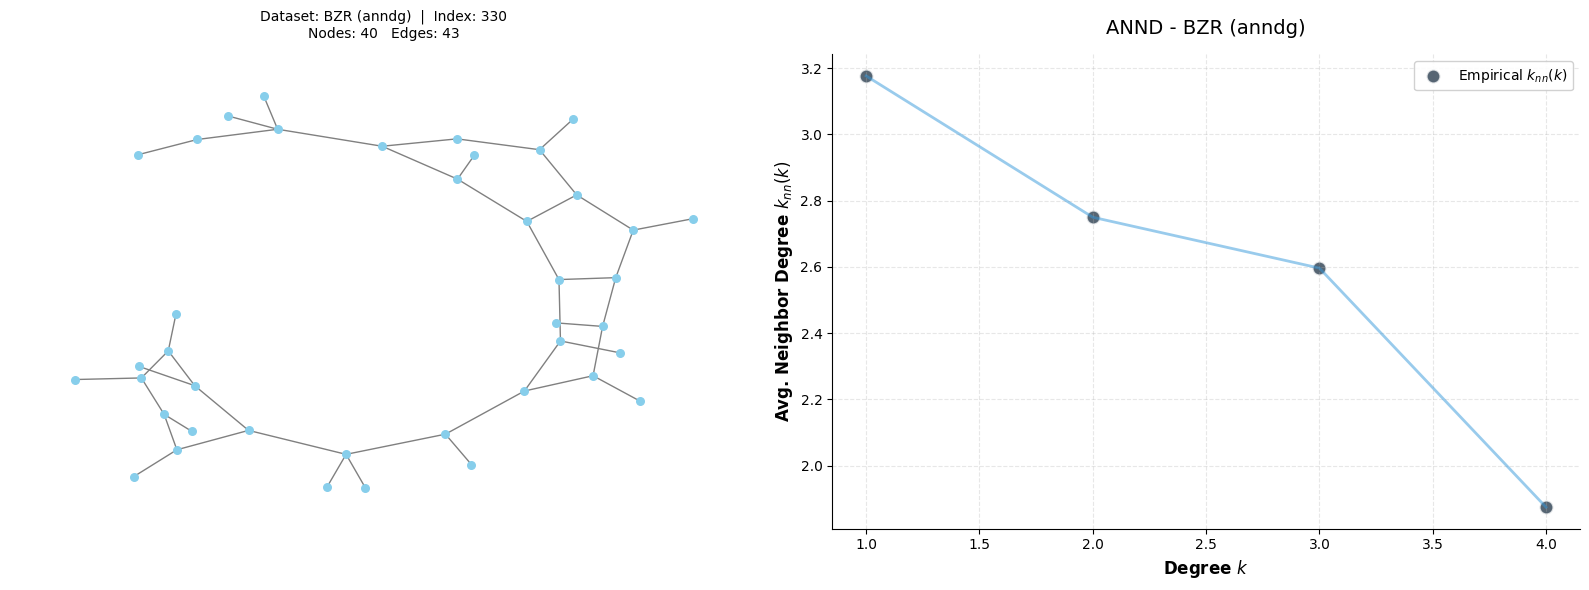

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH_NX, ax=ax1, dataset_name=f"{DATASET} ({METHOD})", graph_index=IDX)
plot_annd(graph=GRAPH_NX, ax=ax2, title=f"ANND - {DATASET} ({METHOD})")

# Calculate and print assortativity
target_stats = analyze_single_graph(GRAPH_IG)

plt.tight_layout()
plt.show()

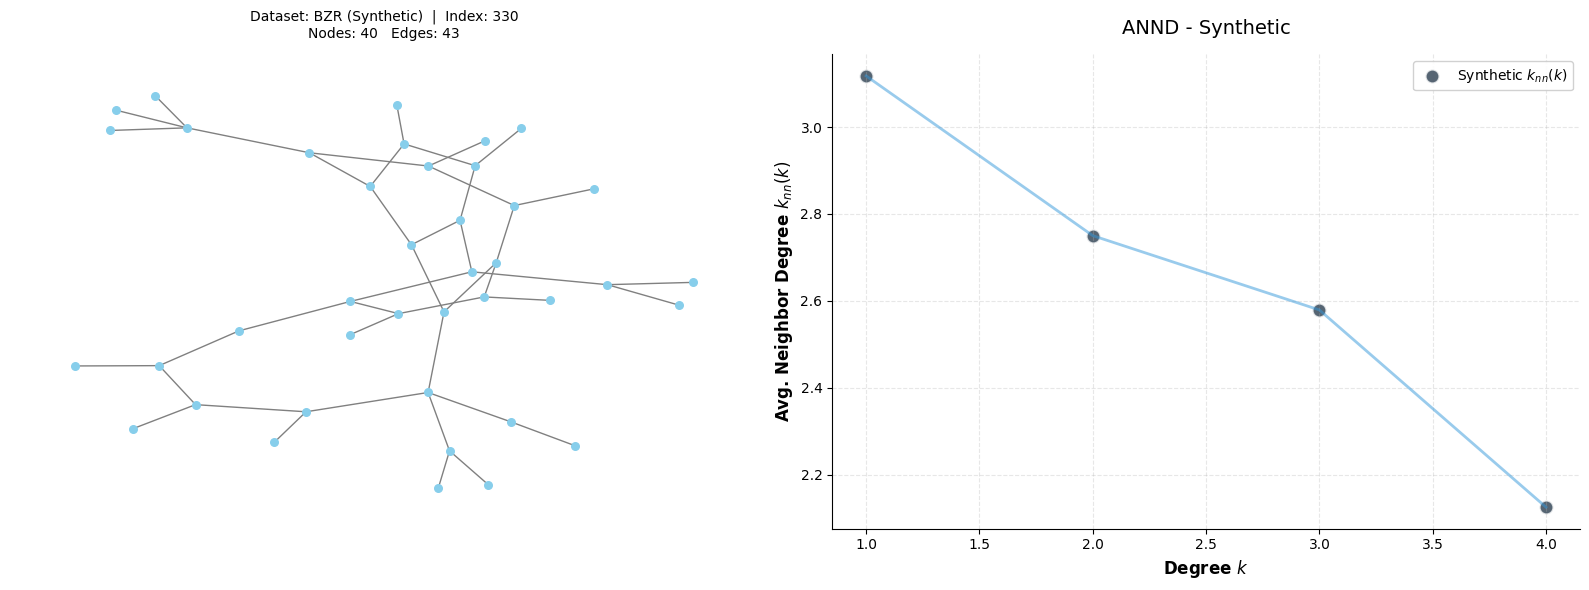


TOPOLOGICAL STATISTIC     | ORIGINAL     | SYNTHETIC    | DELTA     
----------------------------------------------------------------------
Assortativity             |      -0.3518 |      -0.2943 |     0.0575
Modularity                |       0.6471 |       0.6452 |     0.0019
Clustering                |       0.0000 |       0.0000 |     0.0000
Efficiency                |       0.2537 |       0.2792 |     0.0255
Diameter                  |      15.0000 |      10.0000 |     5.0000
----------------------------------------------------------------------

STRUCTURAL ERROR SUMMARY  | VALUE       
----------------------------------------
Moments Error             |       0.0000
ANND Error                |       0.0689
Diameter Error            |       0.3333



In [ ]:
# Generate synthetic graph
rng = np.random.default_rng(seed=None)
GRAPH_SYNTH_NX = generate_graph(target_stats, method=METHOD, rng=rng)
GRAPH_SYNTH_IG = networkx_to_igraph(GRAPH_SYNTH_NX)

# Plot synthetic results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH_SYNTH_NX, ax=ax1, dataset_name=f"{DATASET} (Synthetic)", graph_index=IDX)
plot_annd(graph=GRAPH_SYNTH_NX, ax=ax2, title=f"ANND - Synthetic", label='Synthetic $k_{nn}(k)$')

# Calculate and print assortativity
obtained_stats = analyze_single_graph(GRAPH_SYNTH_IG)

plt.tight_layout()
plt.show()

print(f"\n" + "="*70)
print(f"{'TOPOLOGICAL STATISTIC':<25} | {'ORIGINAL':<12} | {'SYNTHETIC':<12} | {'DELTA':<10}")
print("-" * 70)

# Scalar metrics comparison
scalar_metrics = ['assortativity', 'modularity', 'clustering', 'efficiency', 'diameter']
for m in scalar_metrics:
    orig = target_stats.get(m, 0.0)
    synth = obtained_stats.get(m, 0.0)
    delta = abs(orig - synth)
    print(f"{m.capitalize():<25} | {orig:>12.4f} | {synth:>12.4f} | {delta:>10.4f}")

print("-" * 70)

# Structural error computation
from src.graph_analysis import calculate_moments_error

# Calculate degree sequences for ANND error
deg_seq_original = np.array(GRAPH_IG.degree())
deg_seq_synthetic = np.array(GRAPH_SYNTH_IG.degree())

annd_error = calculate_annd_error(
    obtained_annd=obtained_stats['annd'], 
    obtained_degree_sequence=deg_seq_synthetic, 
    target_annd=target_stats['annd'], 
    target_degree_sequence=deg_seq_original
)
moments_error = calculate_moments_error(target_stats['normalized_degree_moments'], obtained_stats['normalized_degree_moments'])
diameter_error = abs(obtained_stats['diameter'] - target_stats['diameter']) / target_stats['diameter'] if target_stats['diameter'] > 0 else 0.0

print(f"\n{'STRUCTURAL ERROR SUMMARY':<25} | {'VALUE':<12}")
print("-" * 40)
print(f"{'Moments Error':<25} | {moments_error:>12.4f}")
print(f"{'ANND Error':<25} | {annd_error:>12.4f}")
print(f"{'Diameter Error':<25} | {diameter_error:>12.4f}")
print("="*70 + "\n")